# FARMWISE empirical evaluation - analysis

This notebook only **analyses a frozen collection** written by
`python -m evaluation.collect_empirical`; it never queries live APIs. Set
`COLLECTION_ID` to the collection used in the paper so that every table and
figure below can be regenerated from the preserved files alone.

Statistical conventions (see `evaluation/analysis.py` and `evaluation/README.md`):

* runtime and memory: **median and IQR**, with a percentile-bootstrap 95 % CI for the median;
* memory: **peak process RSS** is the primary metric; `tracemalloc` peaks are secondary;
* cross-source results are **agreement** statistics, not accuracy - no source is treated as ground truth.

In [24]:
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style("whitegrid")

# Works whether Jupyter was started in the repository root or in evaluation/.
REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))
from evaluation import analysis


EMPIRICAL_ROOT = REPO_ROOT / "evaluation" / "empirical_input"
COLLECTION_ID = '20260915T143518Z'

def _is_complete(directory):
    manifest_file = directory / "manifest.json"
    if not (directory / "empirical_runs.json").exists() or not manifest_file.exists():
        return False
    experiments = json.loads(manifest_file.read_text(encoding="utf-8")).get("experiments")
    return experiments is None or "scaling" in experiments


COLLECTION_DIR = EMPIRICAL_ROOT / COLLECTION_ID
FIGURES = REPO_ROOT / "evaluation" / "analysis_output" / COLLECTION_ID
FIGURES.mkdir(parents=True, exist_ok=True)

collection = analysis.load_collection(COLLECTION_DIR)
manifest = collection["manifest"]
payload = collection["payload"]
runs_df = collection["runs"]
dispatch_df = collection["dispatch"]
# Used by the quality-report cells at the end of the notebook.
INPUT = COLLECTION_DIR / "empirical_runs.json"

print("Collection:", COLLECTION_ID)
print("Commit:", manifest["git"]["commit_sha"],
      "(uncommitted tracked changes)" if manifest["git"]["tracked_changes_uncommitted"] else "")
print("Python", manifest["software"]["python_version"], "| FARMWISE", manifest["software"]["farmwise_api_version"])
print(manifest["hardware"]["platform"], "|", manifest["hardware"]["cpu_model"],
      "|", manifest["hardware"]["cpu_logical_cores"], "logical cores |",
      manifest["hardware"]["total_ram_gb"], "GB RAM")
print("Measured runs:", len(runs_df), "| warm-ups excluded:", len(payload.get("warmup_runs", [])))
runs_df.groupby(["experiment", "status"]).size().unstack(fill_value=0)

Collection: 20260915T143518Z
Commit: 23a0222def9ebba707b839f1c3d2f7176233d090 (uncommitted tracked changes)
Python 3.12.6 | FARMWISE 0.1.0
Windows-11-10.0.26200-SP0 | Intel64 Family 6 Model 141 Stepping 1, GenuineIntel | 16 logical cores | 31.71 GB RAM
Measured runs: 339 | warm-ups excluded: 35


status,no-data,success
experiment,,
coverage,13,35
cross-source,0,16
quality-overhead,0,20
scaling,0,255


## 1. Scaling

Each sweep changes one request dimension (S2 level, spatial extent, temporal
extent) with a fixed factor set, quality assessment disabled, 10 measured
repeats after one warm-up, in seeded random order. Runtime and memory are
related to the **actual workload** - requested and returned S2 cells, returned
values, requested days - rather than to the nominal scenario parameter.

In [25]:
scaling_runtime = analysis.scaling_summary(runs_df, "request_wall_seconds")
scaling_runtime.columns

Index(['dimension', 'input_value', 'n', 'median', 'q1', 'q3', 'iqr',
       'median_ci_low', 'median_ci_high', 'min', 'max', 'mean', 'std',
       'median_requested_s2_cells', 'median_returned_s2_cells',
       'median_returned_values', 'median_area_km2', 'median_duration_days',
       'median_requested_factors', 'failed_runs'],
      dtype='str')

In [26]:
scaling_memory = analysis.scaling_summary(runs_df, "peak_rss_mb")
scaling_memory

,dimension,input_value,n,median,q1,q3,iqr,median_ci_low,median_ci_high,min,max,mean,std,median_requested_s2_cells,median_returned_s2_cells,median_returned_values,median_area_km2,median_duration_days,median_requested_factors,failed_runs
0,S2 level,6.00,15,493.968750,490.570312,500.968750,10.398438,490.882031,502.523438,473.675781,557.875000,503.685156,24.819339,3.0,2.0,14.0,7371.837002,7.0,1.0,0
1,S2 level,8.00,15,497.515625,492.882812,525.718750,32.835938,493.539062,549.292969,484.656250,804.500000,526.707292,80.921434,13.0,2.0,14.0,7371.837002,7.0,1.0,0
2,S2 level,10.00,15,493.359375,491.736328,547.259766,55.523438,491.117188,551.394531,486.640625,557.164062,511.835156,29.799972,125.0,3.0,21.0,7371.837002,7.0,1.0,0
3,S2 level,12.00,15,493.734375,490.791016,555.523438,64.732422,491.253906,556.617188,486.410156,801.101562,546.008073,106.789315,1708.0,3.0,21.0,7371.837002,7.0,1.0,0
4,S2 level,14.00,15,491.781250,489.304688,550.500000,61.195312,489.214844,554.367188,484.757812,800.933594,528.823177,80.898695,26165.0,3.0,21.0,7371.837002,7.0,1.0,0
5,Spatial extent,0.25,15,494.699219,492.328125,528.435547,36.107422,491.886719,556.582031,475.488281,785.746094,524.710156,77.389725,13.0,1.0,7.0,460.745295,7.0,1.0,0
6,Spatial extent,0.50,15,498.800781,486.576172,550.550781,63.974609,487.648438,552.804688,475.585938,799.371094,527.601562,80.688069,40.0,2.0,14.0,1842.976794,7.0,1.0,0
7,Spatial extent,1.00,15,493.960938,490.275391,501.765625,11.490234,491.999121,503.265625,478.183594,789.781250,521.110937,78.203047,125.0,3.0,21.0,7371.837002,7.0,1.0,0
8,Spatial extent,2.00,15,498.953125,493.310547,560.855469,67.544922,493.164062,557.804688,484.910156,799.027344,533.716406,80.300360,451.0,22.0,147.0,29486.225221,7.0,1.0,0
9,Spatial extent,3.00,15,500.359375,495.710938,525.388672,29.677734,494.769531,518.039062,491.226562,576.320312,513.254427,26.200194,979.0,40.0,273.0,66339.796421,7.0,1.0,0


In [27]:
# Descriptive log-log scaling exponents against the workload measure of each sweep.
fits = pd.DataFrame([
    analysis.scaling_fit(runs_df, "S2 level", x="requested_s2_cells"),
    analysis.scaling_fit(runs_df, "S2 level", x="returned_values"),
    analysis.scaling_fit(runs_df, "Spatial extent", x="requested_s2_cells"),
    analysis.scaling_fit(runs_df, "Spatial extent", x="returned_values"),
    analysis.scaling_fit(runs_df, "Temporal extent", x="duration_days"),
    analysis.scaling_fit(runs_df, "Temporal extent", x="returned_values"),
    analysis.scaling_fit(runs_df, "S2 level", x="requested_s2_cells", y="peak_rss_mb"),
    analysis.scaling_fit(runs_df, "Spatial extent", x="requested_s2_cells", y="peak_rss_mb"),
    analysis.scaling_fit(runs_df, "Temporal extent", x="duration_days", y="peak_rss_mb"),
])
fits

,dimension,x,y,n,slope,intercept,r_squared
0,S2 level,requested_s2_cells,request_wall_seconds,75,-0.004868,0.682150,0.025728
1,S2 level,returned_values,request_wall_seconds,75,-0.105740,0.803475,0.044632
2,Spatial extent,requested_s2_cells,request_wall_seconds,90,0.009671,0.672823,0.008041
3,Spatial extent,returned_values,request_wall_seconds,90,0.008655,0.680095,0.004505
4,Temporal extent,duration_days,request_wall_seconds,90,0.001347,0.680470,0.000232
5,Temporal extent,returned_values,request_wall_seconds,90,0.001352,0.679821,0.000233
6,S2 level,requested_s2_cells,peak_rss_mb,75,0.004609,2.705192,0.017279
7,Spatial extent,requested_s2_cells,peak_rss_mb,90,-0.000523,2.717651,0.000081
8,Temporal extent,duration_days,peak_rss_mb,90,-0.014898,2.743027,0.026009


In [ ]:
# Scaling runtime for the paper. Rows: total request time and FARMWISE's own
# processing (request time minus adapter time), each on its own linear axis.
# Columns: sweeps, against their actual workload. Median, IQR band, repeats.
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

# Figure style shared by the paper figures. Applied locally, on top of
# matplotlib's defaults, so seaborn themes or dark notebook themes set
# elsewhere cannot leak into the saved figures.
PAPER_STYLE = {
    "font.size": 8.5, "axes.titlesize": 9, "axes.labelsize": 8.5,
    "xtick.labelsize": 7.5, "ytick.labelsize": 7.5, "legend.fontsize": 7.5,
    "legend.title_fontsize": 8, "axes.grid": True, "grid.color": "0.92",
    "grid.linewidth": 0.6, "axes.edgecolor": "0.3", "axes.spines.top": False,
    "axes.spines.right": False, "savefig.dpi": 300, "figure.facecolor": "white",
    "axes.facecolor": "white", "savefig.facecolor": "white",
}

# How each sweep is placed on the x-axis: the actual workload, not the nominal
# scenario value. The nominal value is kept as a secondary tick label.
SCALING_AXES = {
    "S2 level": ("requested_s2_cells", "Requested S2 cells", lambda v: f"L{v:g}"),
    "Spatial extent": ("requested_s2_cells", "Requested S2 cells", lambda v: f"{v:g}°"),
    "Temporal extent": ("duration_days", "Requested days", None),
}


def scaling_frame(runs: pd.DataFrame, dispatch: pd.DataFrame) -> pd.DataFrame:
    """Successful scaling runs with FARMWISE-internal time separated out.

    Adapters are awaited one after another, so request time minus the summed
    adapter wall times is the time FARMWISE spends outside the adapters:
    pre-check, harmonisation, aggregation and assembling the result.
    """
    scaling = runs[runs["experiment"] == "scaling"]
    failed = dispatch[(dispatch["experiment"] == "scaling") & (dispatch["status"] != "success")]
    if len(failed):
        summary = failed.groupby(["source_short", "status"]).size().to_dict()
        print(f"WARNING: {len(failed)} adapter calls in scaling runs did not succeed: {summary}. "
              "Those requests did not exercise every backend.")
    frame = scaling[scaling["status"] == "success"].copy()
    frame["internal_seconds"] = (frame["request_wall_seconds"] - frame["dispatch_seconds_sum"]).clip(lower=0)
    return frame


def _band(ax, frame, x_column, value, colour, label):
    grouped = frame.groupby("input_value")
    stats = grouped.agg(x=(x_column, "median"), median=(value, "median"),
                        q1=(value, lambda s: s.quantile(0.25)),
                        q3=(value, lambda s: s.quantile(0.75))).sort_values("x")
    jitter = np.random.default_rng(0).uniform(0.94, 1.06, len(frame))
    ax.scatter(frame[x_column] * jitter, frame[value], s=5, color=colour, alpha=0.25,
               linewidths=0, zorder=2, rasterized=True)
    ax.fill_between(stats["x"], stats["q1"], stats["q3"], color=colour, alpha=0.18,
                    linewidth=0, zorder=1)
    ax.plot(stats["x"], stats["median"], color=colour, marker="o", markersize=3.5,
            linewidth=1.3, zorder=3, label=label)
    return stats


def _nominal_ticks(ax, stats, formatter):
    """Label the nominal scenario value (e.g. S2 level) along the top edge."""
    if formatter is None:
        return
    top = ax.secondary_xaxis("top")
    top.set_xticks(stats["x"].to_numpy(), labels=[formatter(v) for v in stats.index])
    top.xaxis.set_minor_locator(plt.NullLocator())
    top.tick_params(length=2, labelsize=7, colors="0.35", pad=1)
    top.spines["top"].set_visible(False)


def plot_scaling(frame: pd.DataFrame, series, *, path_stem=None):
    """One row per quantity, one column per sweep.

    ``series`` is a list of (column, colour, row label). Each row has its own
    linear y-axis from zero, shared across the sweeps in that row, so the IQR
    bands of quantities on very different scales (seconds of upstream wait vs
    tenths of a second of processing) all stay visible and comparable.
    """
    dimensions = [d for d in SCALING_AXES if d in set(frame["dimension"])]
    with plt.style.context("default"), plt.rc_context(PAPER_STYLE):
        fig, axes = plt.subplots(len(series), len(dimensions),
                                 figsize=(2.45 * len(dimensions), 2.05 * len(series) + 0.35),
                                 squeeze=False, sharex="col", sharey="row",
                                 constrained_layout=True)
        letters = iter("abcdefghijklmnop")
        for row, (column, colour, row_label) in enumerate(series):
            for col, dimension in enumerate(dimensions):
                ax = axes[row, col]
                x_column, x_label, formatter = SCALING_AXES[dimension]
                sub = frame[frame["dimension"] == dimension]
                stats = _band(ax, sub, x_column, column, colour, row_label)
                ax.set_xscale("log")
                # Only decade labels: minor log labels collide on short ranges.
                ax.xaxis.set_minor_formatter(plt.NullFormatter())
                ax.set_ylim(bottom=0, top=float(sub[column].max()) * 1.08)
                # Panel letter as a left-aligned title, so it never covers data;
                # every top-row title uses the same padding so they line up.
                pad = 14 if row == 0 else 4
                ax.set_title(f"({next(letters)})", loc="left", pad=pad, fontweight="bold")
                if row == 0:
                    ax.set_title(dimension, loc="center", pad=pad)
                    _nominal_ticks(ax, stats, formatter)
                if row == len(series) - 1:
                    ax.set_xlabel(x_label)
                if col == 0:
                    ax.set_ylabel(row_label)
            # sharey="row" keeps the largest limit only if every panel agrees.
            top = max(float(frame[column].max()) * 1.08, 1e-9)
            for ax in axes[row]:
                ax.set_ylim(0, top)
        handles = [
            Line2D([], [], color="0.3", marker="o", markersize=3.5, linewidth=1.3, label="Median"),
            Patch(color="0.6", alpha=0.3, label="Interquartile range"),
            Line2D([], [], color="0.3", marker="o", linestyle="", markersize=3, alpha=0.4,
                   label="Individual repeats"),
        ]
        fig.legend(handles=handles, loc="outside lower center", ncols=len(handles), frameon=False)
        if path_stem is not None:
            for suffix in (".pdf", ".png"):
                fig.savefig(Path(str(path_stem) + suffix), bbox_inches="tight")
    return fig


scaling_runs = scaling_frame(runs_df, dispatch_df)
fig = plot_scaling(
    scaling_runs,
    [("request_wall_seconds", "#0072B2", "Total request [s]"),
     ("internal_seconds", "#D55E00", "FARMWISE processing [s]")],
    path_stem=FIGURES / "scaling_runtime",
)
plt.show()


In [ ]:
# Scaling memory for the paper. Rows: peak process RSS (primary metric) and the
# peak Python heap from tracemalloc. Uses the helpers and `scaling_runs` defined
# in the runtime cell above.
fig = plot_scaling(
    scaling_runs,
    [("peak_rss_mb", "#009E73", "Peak process RSS [MB]"),
     ("peak_traced_memory_mb", "#CC79A7", "Peak Python heap [MB]")],
    path_stem=FIGURES / "scaling_memory",
)
plt.show()


In [30]:
# Adapter/source timings within the scaling sweeps.
analysis.robust_summary(
    dispatch_df[dispatch_df["experiment"] == "scaling"],
    ["source_short", "dimension", "input_value"],
    "wall_seconds",
)

,source_short,dimension,input_value,n,median,q1,q3,iqr,median_ci_low,median_ci_high,min,max,mean,std
0,epa_gw,S2 level,6.00,15,4.636844,4.191213,5.054641,0.863428,4.147077,4.971590,4.101991,5.630339,4.659692,0.497299
1,epa_gw,S2 level,8.00,15,4.962057,4.348900,5.163443,0.814543,4.353139,5.227397,3.832026,5.908621,4.816580,0.539453
2,epa_gw,S2 level,10.00,15,4.432222,4.264465,4.513130,0.248665,4.258106,4.482740,3.768191,6.057044,4.528794,0.553519
3,epa_gw,S2 level,12.00,15,4.541994,4.283207,4.857459,0.574251,4.372645,4.806663,3.626597,5.119348,4.527382,0.419827
4,epa_gw,S2 level,14.00,15,4.545581,4.320001,4.610305,0.290303,4.349376,4.605740,4.009782,5.286696,4.531575,0.353457
5,epa_gw,Spatial extent,0.25,15,4.395006,4.298633,4.574513,0.275880,4.289156,4.533591,4.220192,7.850351,4.677885,0.905879
6,epa_gw,Spatial extent,0.50,15,4.486541,4.222897,4.998727,0.775830,4.226662,5.205020,3.732893,14.442217,5.268151,2.647912
7,epa_gw,Spatial extent,1.00,15,4.747049,4.181088,4.973134,0.792045,4.230074,4.988189,4.081673,13.354049,5.190043,2.301742
8,epa_gw,Spatial extent,2.00,15,4.618725,4.398352,4.964933,0.566581,4.397952,4.866708,3.759758,6.490107,4.730280,0.623218
9,epa_gw,Spatial extent,3.00,15,4.515564,4.384176,4.816951,0.432775,4.384467,4.831791,3.987531,5.400519,4.589995,0.378765


## 2. Quality-assessment overhead

One representative request (the scaling base case), 10 repeats each with
quality assessment off and on (assessment + persisted report, the server
default). The overhead is reported separately from the scaling results.

In [31]:
quality_cost = analysis.quality_overhead(runs_df)
pd.DataFrame({
    mode: quality_cost[f"runtime_{mode}"] for mode in ("off", "on")
}).T.assign(
    median_overhead_seconds=quality_cost["median_overhead_seconds"],
    overhead_ci_low=quality_cost["overhead_ci_low"],
    overhead_ci_high=quality_cost["overhead_ci_high"],
)

,n,median,q1,q3,iqr,median_ci_low,median_ci_high,min,max,mean,std,median_overhead_seconds,overhead_ci_low,overhead_ci_high
off,10.0,5.279244,5.082655,6.083029,1.000374,4.895676,6.448689,4.349647,7.643715,5.669790,1.150988,0.16647,-0.989851,1.140376
on,10.0,5.445713,5.325664,6.251306,0.925642,5.210483,6.338176,4.200617,7.446097,5.748034,0.937936,0.16647,-0.989851,1.140376


## 3. Coverage pre-check vs factor-only routing

Each coverage scenario runs with FARMWISE's registry-based pre-check and with a
factor-only baseline that dispatches every enabled source providing a requested
factor, ignoring spatial and temporal coverage. Disabled (e.g. licence-restricted)
sources are excluded in both modes. `requests_avoided_vs_factor_only` counts
adapter calls the pre-check saves; `unproductive_dispatches` are adapter calls
that ended empty, failed or timed out.

In [32]:
analysis.coverage_comparison(runs_df)

,scenario,mode,runs,planned_configured_sources,planned_factor_eligible_sources,planned_precheck_dispatched_sources,planned_requests_avoided_vs_factor_only,median_dispatched_sources,median_unproductive_dispatches,total_empty,...,runtime_median,runtime_q1,runtime_q3,runtime_iqr,runtime_median_ci_low,runtime_median_ci_high,runtime_min,runtime_max,runtime_mean,runtime_std
0,austria-meteo-overlap,factor-only,3,18,5,2,3,5.0,3.0,3,...,59.510308,58.869205,60.962082,2.092877,58.228102,62.413856,58.228102,62.413856,60.050755,2.144574
1,austria-meteo-overlap,precheck,3,18,5,2,3,2.0,0.0,0,...,42.043365,40.936397,49.652350,8.715953,39.829429,57.261334,39.829429,57.261334,46.378043,9.489990
2,germany-land-cover,factor-only,3,18,2,1,1,2.0,1.0,3,...,61.436470,60.906333,64.656099,3.749766,60.376197,67.875728,60.376197,67.875728,63.229465,4.058555
3,germany-land-cover,precheck,3,18,2,1,1,1.0,1.0,3,...,10.389281,10.133041,10.615937,0.482897,9.876801,10.842594,9.876801,10.842594,10.369558,0.483199
4,germany-meteo-overlap,factor-only,3,18,5,2,3,5.0,3.0,3,...,69.016368,59.503968,69.225578,9.721610,49.991568,69.434789,49.991568,69.434789,62.814242,11.106731
5,germany-meteo-overlap,precheck,3,18,5,2,3,2.0,0.0,0,...,61.218201,61.131585,70.064003,8.932418,61.044970,78.909806,61.044970,78.909806,67.057659,10.264626
6,germany-soil,factor-only,3,18,2,1,1,2.0,1.0,0,...,66.561050,59.259462,89.574581,30.315119,51.957873,112.588111,51.957873,112.588111,77.035678,31.643243
7,germany-soil,precheck,3,18,2,1,1,1.0,0.0,0,...,47.877897,47.258413,50.175766,2.917353,46.638929,52.473635,46.638929,52.473635,48.996820,3.074075
8,ireland-groundwater,factor-only,3,18,3,1,2,3.0,2.0,3,...,24.536644,24.487070,24.879800,0.392730,24.437495,25.222955,24.437495,25.222955,24.732365,0.427746
9,ireland-groundwater,precheck,3,18,3,1,2,1.0,0.0,0,...,3.675502,3.418167,3.675533,0.257366,3.160831,3.675564,3.160831,3.675564,3.503966,0.297163


In [33]:
precheck_saved = analysis.coverage_effect(runs_df)
precheck_saved.columns

Index(['scenario', 'n_precheck', 'n_factor_only', 'median_runtime_precheck',
       'median_runtime_factor_only', 'median_runtime_saved', 'saved_ci_low',
       'saved_ci_high', 'median_precheck_seconds',
       'requests_avoided_vs_factor_only'],
      dtype='str')

In [34]:
numeric = precheck_saved.select_dtypes(include="number")

summary = pd.DataFrame({
    "median": numeric.median(),
    "q1": numeric.quantile(0.25),
    "q3": numeric.quantile(0.75),
})

summary["iqr"] = summary["q3"] - summary["q1"]
summary

,median,q1,q3,iqr
n_precheck,3.000000,3.000000,3.000000,0.000000
n_factor_only,3.000000,3.000000,3.000000,0.000000
median_runtime_precheck,26.216323,2.777874,51.212973,48.435099
median_runtime_factor_only,53.957428,39.698732,62.717615,23.018883
median_runtime_saved,19.772148,15.049749,29.501969,14.452221
saved_ci_low,10.864349,-7.616381,29.302984,36.919365
saved_ci_high,35.493870,22.453852,50.212010,27.758158
median_precheck_seconds,0.000465,0.000445,0.000470,0.000025
requests_avoided_vs_factor_only,2.500000,1.750000,3.000000,1.250000


In [35]:
# Pre-check overhead relative to the whole request (pre-check mode only).
precheck_runs = runs_df[(runs_df["experiment"] == "coverage") & (runs_df["mode"] == "precheck")].copy()
precheck_runs["precheck_share_pct"] = 100 * precheck_runs["precheck_seconds"] / precheck_runs["request_wall_seconds"]
pd.DataFrame({
    "precheck_microseconds": analysis.robust_stats(1e6 * precheck_runs["precheck_seconds"]),
    "precheck_share_of_request_pct": analysis.robust_stats(precheck_runs["precheck_share_pct"]),
}).T

,n,median,q1,q3,iqr,median_ci_low,median_ci_high,min,max,mean,std
precheck_microseconds,24.0,457.800001,444.125001,472.975001,28.850000,444.699999,470.900002,418.800002,2477.599999,549.116667,412.496494
precheck_share_of_request_pct,24.0,0.002637,0.000918,0.148372,0.147455,0.000941,0.012847,0.000591,2.183929,0.233589,0.500844


## 4. Cross-source agreement

National sources against ERA5 in four regions and four seasonal months
(January, April, July, October 2018). Values are paired strictly on
scenario, timestamp, S2 cell and variable; differences are `national - ERA5`.
Daily precipitation totals from national services and ERA5 may use different
daily accumulation windows; this is not corrected and contributes to the
disagreement reported here.

In [36]:
observations = collection["observations"]
pairs = analysis.pair_observations(observations)
print("Paired observations:", len(pairs))
pairs.groupby(["region", "period", "variable", "source_pair"]).size().unstack("period")

Paired observations: 4920


period                                                  April  January  July  \
region                variable      source_pair                                
austria-meteo         precipitation GeoSphere - ERA5      120      124   124   
                      temperature   GeoSphere - ERA5      120      124   124   
germany-meteo         precipitation DWD - ERA5             60       62    62   
                      temperature   DWD - ERA5             60       62    62   
ireland-precipitation precipitation Met Éireann - ERA5    720      744   744   
poland-imgw-era5      precipitation IMGW - ERA5            60       62    62   
                      temperature   IMGW - ERA5            60       62    62   

period                                                  October  
region                variable      source_pair                  
austria-meteo         precipitation GeoSphere - ERA5        124  
                      temperature   GeoSphere - ERA5        124  
germany-meteo         precipitation DWD - ERA5               62  
                      temperature   DWD - ERA5               62  
ireland-precipitation precipitation Met Éireann - ERA5      744  
poland-imgw-era5      precipitation IMGW - ERA5              62  
                      temperature   IMGW - ERA5              62

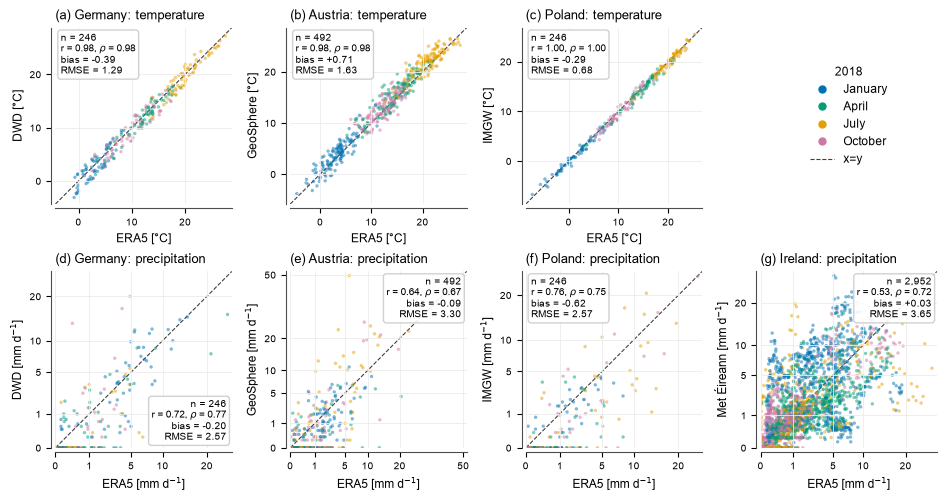

In [37]:
# Cross-source agreement scatter plots for the paper: one panel per region and
# variable, national source (y) against ERA5 (x), coloured by season, with the
# same agreement statistics as analysis.agreement_metrics. Precipitation uses
# square-root axes because daily totals are concentrated near zero.
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

REFERENCE = "ERA5"
KEY = ["scenario", "region", "period", "timestamp", "cell", "variable"]
REGION_ORDER = ["germany-meteo", "austria-meteo", "poland-imgw-era5", "ireland-precipitation"]
REGION_LABELS = {
    "germany-meteo": "Germany",
    "austria-meteo": "Austria",
    "poland-imgw-era5": "Poland",
    "ireland-precipitation": "Ireland",
}
VARIABLES = {"temperature": ("Daily mean temperature", "°C"),
             "precipitation": ("Daily precipitation", "mm d$^{-1}$")}
PERIOD_ORDER = ["January", "April", "July", "October"]
# Okabe-Ito colours: distinguishable with colour-vision deficiency and in greyscale.
PERIOD_COLOURS = {"January": "#0072B2", "April": "#009E73", "July": "#E69F00", "October": "#CC79A7"}


def pair_with_reference(observations: pd.DataFrame, reference: str = REFERENCE) -> pd.DataFrame:
    """Pair each non-reference source with the reference on identical keys.

    One vectorised merge instead of a Python loop over every key: the result
    matches ``analysis.pair_observations`` for national-vs-ERA5 pairs.
    """
    obs = observations.assign(value=pd.to_numeric(observations["value"], errors="coerce"))
    obs = obs.dropna(subset=["value"])
    # One value per source and key, as in analysis.pair_observations.
    obs = obs.groupby(KEY + ["source"], dropna=False, as_index=False)["value"].mean()
    ref = obs[obs["source"] == reference].drop(columns="source").rename(columns={"value": "value_b"})
    other = obs[obs["source"] != reference].rename(columns={"source": "source_a", "value": "value_a"})
    pairs = other.merge(ref, on=KEY, how="inner")
    pairs["source_b"] = reference
    pairs["source_pair"] = pairs["source_a"] + " - " + reference
    pairs["difference"] = pairs["value_a"] - pairs["value_b"]
    return pairs


SQRT_VARIABLES = {"precipitation"}  # zero-heavy: square-root axes spread the bulk near 0
SQRT_TICKS = [0, 1, 5, 10, 20, 50, 100]


def _sqrt(values):
    return np.sqrt(np.clip(values, 0, None))


def _sqrt_axes(ax, high):
    ax.set_xscale("function", functions=(_sqrt, np.square))
    ax.set_yscale("function", functions=(_sqrt, np.square))
    # Locators must be set after the scale: set_*scale resets them.
    ticks = [t for t in SQRT_TICKS if t <= high]
    for axis in (ax.xaxis, ax.yaxis):
        axis.set_major_locator(plt.FixedLocator(ticks))
        axis.set_major_formatter(plt.FuncFormatter(lambda v, _pos: f"{v:g}"))


def _emptiest_corner(x, y, limits, sqrt):
    """Corner of the panel (in drawn coordinates) holding the fewest points."""
    transform = _sqrt if sqrt else (lambda v: np.asarray(v, dtype=float))
    lo, hi = transform(limits[0]), transform(limits[1])
    u = (transform(x) - lo) / (hi - lo)
    v = (transform(y) - lo) / (hi - lo)
    size = 0.42
    corners = {
        ("left", "top"): (u < size) & (v > 1 - size),
        ("right", "top"): (u > 1 - size) & (v > 1 - size),
        ("right", "bottom"): (u > 1 - size) & (v < size),
        ("left", "bottom"): (u < size) & (v < size),
    }
    return min(corners, key=lambda corner: int(np.sum(corners[corner])))


def _panel(ax, sub, variable, unit):
    national = sub["source_a"].iloc[0]
    # One scatter in a fixed random order, so no season is systematically
    # drawn on top of the others.
    order = np.random.default_rng(0).permutation(len(sub))
    shuffled = sub.iloc[order]
    ax.scatter(shuffled["value_b"], shuffled["value_a"], s=6, alpha=0.5, linewidths=0,
               c=shuffled["period"].map(PERIOD_COLOURS), rasterized=True)
    low = min(sub["value_a"].min(), sub["value_b"].min())
    high = max(sub["value_a"].max(), sub["value_b"].max())
    if variable in SQRT_VARIABLES:
        limits = (0.0, high * 1.05)
        _sqrt_axes(ax, limits[1])
        diagonal = np.linspace(*limits, 200)
    else:
        pad = 0.04 * (high - low)
        limits = (low - pad, high + pad)
        diagonal = np.array(limits)
    ax.plot(diagonal, diagonal, color="0.25", linewidth=0.8, linestyle="--", zorder=0)
    ax.set_xlim(limits)
    ax.set_ylim(limits)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"{REFERENCE} [{unit}]")
    ax.set_ylabel(f"{national} [{unit}]")

    m = analysis.agreement_metrics(sub, by=["variable"]).iloc[0]
    text = (f"n = {m['n_pairs']:,}\n"
            f"r = {m['pearson_r']:.2f}, $\\rho$ = {m['spearman_rho']:.2f}\n"
            f"bias = {m['mean_bias']:+.2f}\n"
            f"RMSE = {m['rmse']:.2f}")
    ha, va = _emptiest_corner(sub["value_b"], sub["value_a"], limits,
                              sqrt=variable in SQRT_VARIABLES)
    x = 0.03 if ha == "left" else 0.97
    y = 0.97 if va == "top" else 0.03
    # Offset the axis lines so values of exactly zero stay visible.
    for side in ("left", "bottom"):
        ax.spines[side].set_position(("outward", 3))
    ax.text(x, y, text, transform=ax.transAxes, ha=ha, va=va, fontsize=7,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.8", alpha=0.9))


def plot_cross_source_scatter(pairs: pd.DataFrame, path_stem=None):
    variables = [v for v in VARIABLES if v in set(pairs["variable"])]
    regions = [r for r in REGION_ORDER if r in set(pairs["region"])]
    style = {"font.size": 8.5, "axes.titlesize": 9, "axes.labelsize": 8.5,
             "xtick.labelsize": 7.5, "ytick.labelsize": 7.5, "axes.grid": True,
             "grid.color": "0.92", "grid.linewidth": 0.6, "axes.edgecolor": "0.3",
             "axes.spines.top": False, "axes.spines.right": False, "savefig.dpi": 300}
    with plt.style.context("default"), plt.rc_context(style):
        fig, axes = plt.subplots(len(variables), len(regions),
                                 figsize=(2.35 * len(regions), 2.45 * len(variables)),
                                 squeeze=False, constrained_layout=True)
        letters = iter("abcdefghijklmnop")
        empty = []
        for row, variable in enumerate(variables):
            label, unit = VARIABLES[variable]
            for col, region in enumerate(regions):
                ax = axes[row, col]
                sub = pairs[(pairs["variable"] == variable) & (pairs["region"] == region)]
                if sub.empty:
                    ax.set_axis_off()
                    empty.append(ax)
                    continue
                _panel(ax, sub, variable, unit)
                ax.set_title(f"({next(letters)}) {REGION_LABELS.get(region, region)}: "
                             f"{label.split()[-1].lower()}", loc="left")
        handles = [Line2D([], [], marker="o", linestyle="", markersize=5, color=c, label=p)
                   for p, c in PERIOD_COLOURS.items()]
        handles.append(Line2D([], [], color="0.25", linestyle="--", linewidth=0.8, label="x=y"))
        if empty:
            empty[0].legend(handles=handles, title="2018", loc="center", frameon=False)
        else:
            fig.legend(handles=handles, title="2018", loc="outside right center", frameon=False)
        if path_stem is not None:
            for suffix in (".pdf", ".png"):
                fig.savefig(Path(str(path_stem) + suffix), bbox_inches="tight")
    return fig

scatter_pairs = pair_with_reference(observations)
fig = plot_cross_source_scatter(scatter_pairs, FIGURES / "cross_source_scatter")
plt.show()


In [38]:
agreement_by_season = analysis.agreement_metrics(
    pairs, by=["region", "variable", "source_pair", "period"]
)
agreement_by_season

,region,variable,source_pair,period,n_pairs,n_cells,mean_bias,median_bias,mae,rmse,pearson_r,spearman_rho
0,austria-meteo,precipitation,GeoSphere - ERA5,April,120,4,-0.657130,-0.013351,0.828848,2.360620,0.625580,0.539277
1,austria-meteo,precipitation,GeoSphere - ERA5,January,124,4,-0.354428,-0.079427,1.087776,1.695093,0.681563,0.726660
2,austria-meteo,precipitation,GeoSphere - ERA5,July,124,4,0.720779,-0.096798,2.119291,5.296438,0.668470,0.658778
3,austria-meteo,precipitation,GeoSphere - ERA5,October,124,4,-0.072101,-0.001431,1.043414,2.625400,0.776380,0.635894
4,austria-meteo,temperature,GeoSphere - ERA5,April,120,4,0.817335,0.708003,1.305004,1.699666,0.915563,0.909544
5,austria-meteo,temperature,GeoSphere - ERA5,January,124,4,0.563412,0.580537,1.240912,1.521185,0.891966,0.866929
6,austria-meteo,temperature,GeoSphere - ERA5,July,124,4,0.874592,0.893254,1.328100,1.645883,0.873538,0.849289
7,austria-meteo,temperature,GeoSphere - ERA5,October,124,4,0.569056,0.479684,1.307020,1.656699,0.825082,0.843253
8,germany-meteo,precipitation,DWD - ERA5,April,60,2,-0.675721,-0.010967,1.328596,2.680349,0.815722,0.635259
9,germany-meteo,precipitation,DWD - ERA5,January,62,2,-0.172414,-0.044227,1.427807,2.103853,0.866657,0.840979


In [39]:
agreement_pooled = analysis.agreement_metrics(pairs, by=["region", "variable", "source_pair"])
agreement_pooled

,region,variable,source_pair,n_pairs,n_cells,mean_bias,median_bias,mae,rmse,pearson_r,spearman_rho
0,austria-meteo,precipitation,GeoSphere - ERA5,492,4,-0.086115,-0.040293,1.273418,3.300091,0.643278,0.670896
1,austria-meteo,temperature,GeoSphere - ERA5,492,4,0.705194,0.661601,1.295179,1.631651,0.978794,0.977007
2,germany-meteo,precipitation,DWD - ERA5,246,2,-0.200561,-0.003576,1.154840,2.565621,0.718049,0.772440
3,germany-meteo,temperature,DWD - ERA5,246,2,-0.392468,-0.539527,1.124547,1.294543,0.984437,0.983854
4,ireland-precipitation,precipitation,Met Éireann - ERA5,2952,24,0.027857,-0.052034,2.056548,3.646757,0.530829,0.720310
5,poland-imgw-era5,precipitation,IMGW - ERA5,246,2,-0.619555,-0.073910,1.254147,2.565223,0.756106,0.748522
6,poland-imgw-era5,temperature,IMGW - ERA5,246,2,-0.291859,-0.242184,0.530981,0.683246,0.996777,0.996542


In [40]:
precipitation = analysis.precipitation_agreement(pairs, by=["region", "source_pair", "period"])
precipitation

,region,source_pair,period,n_pairs,wet_threshold_mm,both_wet,wet_only_a,wet_only_b,both_dry,wet_day_agreement,wet_day_kappa,total_a_mm,total_b_mm,median_cell_accumulation_difference_mm,median_cell_relative_accumulation_difference,cells
0,austria-meteo,GeoSphere - ERA5,April,120,1.0,10,3,14,93,0.858333,0.465409,47.500000,126.355648,-18.313436,-0.597986,4
1,austria-meteo,GeoSphere - ERA5,January,124,1.0,40,4,23,57,0.782258,0.566546,163.800000,207.749128,-12.748255,-0.241895,4
2,austria-meteo,GeoSphere - ERA5,July,124,1.0,28,5,20,71,0.798387,0.549156,350.300000,260.923386,25.591827,0.509447,4
3,austria-meteo,GeoSphere - ERA5,October,124,1.0,14,5,21,84,0.790323,0.399180,144.200000,153.140545,0.844655,0.038801,4
4,germany-meteo,DWD - ERA5,April,60,1.0,12,4,13,31,0.716667,0.385542,80.900000,121.443272,-20.271636,-0.352784,2
5,germany-meteo,DWD - ERA5,January,62,1.0,31,1,8,22,0.854839,0.707240,216.400000,227.089643,-5.344822,-0.066501,2
6,germany-meteo,DWD - ERA5,July,62,1.0,8,3,5,46,0.870968,0.587354,50.300000,64.657211,-7.178606,-0.209139,2
7,germany-meteo,DWD - ERA5,October,62,1.0,6,4,7,45,0.822581,0.415094,54.400000,38.147926,8.126037,0.478843,2
8,ireland-precipitation,Met Éireann - ERA5,April,720,1.0,323,67,109,221,0.755556,0.502825,1588.505818,2143.498898,-26.005969,-0.291808,24
9,ireland-precipitation,Met Éireann - ERA5,January,744,1.0,421,95,105,123,0.731183,0.359769,3677.802117,2847.947598,30.839328,0.245880,24


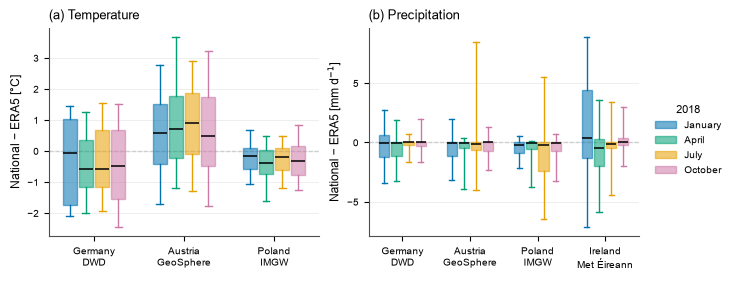

In [41]:
# National minus ERA5 differences per region and season for the paper. Boxes:
# IQR with median; whiskers: 5th-95th percentiles; values beyond are not drawn.
# Uses `pairs` from the pairing cell and PAPER_STYLE from the scaling cell.
DIFF_REGION_ORDER = ["germany-meteo", "austria-meteo", "poland-imgw-era5", "ireland-precipitation"]
DIFF_REGION_LABELS = {"germany-meteo": "Germany\nDWD", "austria-meteo": "Austria\nGeoSphere",
                      "poland-imgw-era5": "Poland\nIMGW", "ireland-precipitation": "Ireland\nMet Éireann"}
DIFF_VARIABLES = {"temperature": ("Temperature", "°C"), "precipitation": ("Precipitation", "mm d$^{-1}$")}
DIFF_PERIODS = ["January", "April", "July", "October"]
DIFF_COLOURS = {"January": "#0072B2", "April": "#009E73", "July": "#E69F00", "October": "#CC79A7"}


def plot_difference_boxes(pairs: pd.DataFrame, path_stem=None):
    """National minus ERA5 differences per region, one box per season.

    Boxes span the interquartile range with the median marked; whiskers reach
    the 5th and 95th percentiles; values beyond them are not drawn.
    """
    variables = [v for v in DIFF_VARIABLES if v in set(pairs["variable"])]
    with plt.style.context("default"), plt.rc_context(PAPER_STYLE):
        fig, axes = plt.subplots(1, len(variables), figsize=(3.6 * len(variables), 2.7),
                                 squeeze=False, constrained_layout=True)
        width = 0.18
        for letter, ax, variable in zip("abcdefgh", axes[0], variables):
            label, unit = DIFF_VARIABLES[variable]
            sub = pairs[pairs["variable"] == variable]
            regions = [r for r in DIFF_REGION_ORDER if r in set(sub["region"])]
            for i, region in enumerate(regions):
                for j, period in enumerate(DIFF_PERIODS):
                    values = sub.loc[(sub["region"] == region) & (sub["period"] == period),
                                     "difference"].dropna()
                    if values.empty:
                        continue
                    position = i + (j - (len(DIFF_PERIODS) - 1) / 2) * width
                    colour = DIFF_COLOURS[period]
                    ax.boxplot(values, positions=[position], widths=width * 0.85,
                               whis=(5, 95), showfliers=False, patch_artist=True,
                               boxprops=dict(facecolor=colour, edgecolor=colour, alpha=0.55),
                               medianprops=dict(color="black", linewidth=1.1),
                               whiskerprops=dict(color=colour, linewidth=1),
                               capprops=dict(color=colour, linewidth=1))
            ax.axhline(0, color="0.25", linewidth=0.8, linestyle="--", zorder=0)
            ax.set_xticks(range(len(regions)), labels=[DIFF_REGION_LABELS.get(r, r) for r in regions])
            ax.set_xlim(-0.5, len(regions) - 0.5)
            ax.grid(axis="x", visible=False)
            ax.set_ylabel(f"National − ERA5 [{unit}]")
            ax.set_title(f"({letter}) {label}", loc="left")
        handles = [Patch(facecolor=c, edgecolor=c, alpha=0.55, label=p) for p, c in DIFF_COLOURS.items()]
        fig.legend(handles=handles, title="2018", loc="outside right center", frameon=False)
        if path_stem is not None:
            for suffix in (".pdf", ".png"):
                fig.savefig(Path(str(path_stem) + suffix), bbox_inches="tight")
    return fig


fig = plot_difference_boxes(pairs, FIGURES / "cross_source_differences")
plt.show()


## 5. Quality reports

Per-source quality reports persisted during this collection (cross-source runs
and the quality-on runs of the overhead experiment).

In [42]:
from pathlib import Path
import json

import numpy as np
import pandas as pd


# ============================================================
# CONFIG
# ============================================================

QUALITY_DIR = INPUT.parent / payload.get(
    "quality_report_dir",
    "quality",
)
OUT_DIR = Path("quality_summary")

OUT_DIR.mkdir(exist_ok=True)


# ============================================================
# HELPERS
# ============================================================

def load_quality_report(path: Path) -> dict:
    """
    Supports:
      - JSON quality reports
      - one-row CSV quality reports

    The attached example is JSON.
    """

    # First try JSON, regardless of extension
    try:
        with path.open("r", encoding="utf-8") as f:
            obj = json.load(f)

        if isinstance(obj, dict):
            return obj

    except (json.JSONDecodeError, UnicodeDecodeError):
        pass


def to_datetime(value):
    return pd.to_datetime(
        value,
        errors="coerce",
    )


def safe_div(a, b):
    if pd.isna(a) or pd.isna(b) or b == 0:
        return np.nan
    return a / b


def weighted_fraction(values, weights):
    """Weighted mean of report-level fractions, bounded to [0, 1]."""
    values = pd.to_numeric(values, errors="coerce").clip(0, 1)
    weights = pd.to_numeric(weights, errors="coerce")
    valid = values.notna() & weights.notna() & (weights > 0)
    if not valid.any():
        return np.nan
    return float(np.average(values[valid], weights=weights[valid]))


def p05(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    return x.quantile(0.05) if len(x) else np.nan


def p95(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    return x.quantile(0.95) if len(x) else np.nan


def cv_pct(x):
    x = pd.to_numeric(x, errors="coerce").dropna()

    if len(x) < 2 or x.mean() == 0:
        return np.nan

    return (
        100
        * x.std(ddof=1)
        / abs(x.mean())
    )


def summarise_group(group):
    """
    Summarise a set of quality reports.
    """

    result = {
        # number of reports
        "n_reports": len(group),

        # ----------------------------------------------------
        # S2 spatial support (descriptive, not a quality defect)
        # ----------------------------------------------------

        "S2_support_mean":
            group["S2_support_fraction"].mean(),

        "S2_support_median":
            group["S2_support_fraction"].median(),

        "S2_support_std":
            group["S2_support_fraction"].std(),

        "S2_support_p05":
            p05(group["S2_support_fraction"]),

        "S2_support_p95":
            p95(group["S2_support_fraction"]),

        "S2_support_min":
            group["S2_support_fraction"].min(),

        "S2_support_max":
            group["S2_support_fraction"].max(),

        # weighted by expected cells; uses the report-level intersection
        # fraction, so cells outside the request cannot push it above 1
        "S2_support_weighted":
            weighted_fraction(
                group["S2_support_fraction"],
                group["expected_s2_cells"],
            ),

        "expected_s2_cells_total":
            group["expected_s2_cells"].sum(),

        "returned_s2_cells_total":
            group["returned_s2_cells"].sum(),

        "unrepresented_s2_cells_total":
            group["unrepresented_s2_cells"].sum(),

        # ----------------------------------------------------
        # TEMPORAL COMPLETENESS
        # ----------------------------------------------------

        "missing_days_mean":
            group["missing_days"].mean(),

        "missing_days_median":
            group["missing_days"].median(),

        "missing_days_p95":
            p95(group["missing_days"]),

        "missing_days_max":
            group["missing_days"].max(),

        "reports_with_missing_days":
            (group["missing_days"] > 0).sum(),

        "reports_with_missing_days_pct":
            100 * (group["missing_days"] > 0).mean(),

        # independently derived from expected/returned
        # date boundaries
        "start_delay_days_mean":
            group["start_delay_days"].mean(),

        "end_cutshort_days_mean":
            group["end_cutshort_days"].mean(),

        "temporal_span_completeness_mean":
            group["temporal_span_completeness"].mean(),

        "temporal_span_completeness_min":
            group["temporal_span_completeness"].min(),

        # ----------------------------------------------------
        # MISSING VALUES
        # ----------------------------------------------------

        "total_missing_values_mean":
            group["total_missing_values"].mean(),

        "total_missing_values_median":
            group["total_missing_values"].median(),

        "total_missing_values_p95":
            p95(group["total_missing_values"]),

        "total_missing_values_max":
            group["total_missing_values"].max(),

        "reports_with_missing_values":
            (group["total_missing_values"] > 0).sum(),

        "reports_with_missing_values_pct":
            100
            * (group["total_missing_values"] > 0).mean(),

        "factor_missing_values_mean":
            group["factor_missing_values"].mean(),

        # ----------------------------------------------------
        # ERROR / IMPLAUSIBLE VALUES
        # ----------------------------------------------------

        "error_values_mean":
            group["error_values"].mean(),

        "error_values_median":
            group["error_values"].median(),

        "error_values_p95":
            p95(group["error_values"]),

        "error_values_max":
            group["error_values"].max(),

        "reports_with_error_values":
            (group["error_values"] > 0).sum(),

        "reports_with_error_values_pct":
            100
            * (group["error_values"] > 0).mean(),

        # ----------------------------------------------------
        # FACTOR COMPLETENESS
        # ----------------------------------------------------

        "factor_completeness_mean":
            group["factors_returned_completeness"].mean(),

        "factor_completeness_median":
            group["factors_returned_completeness"].median(),

        "factor_completeness_min":
            group["factors_returned_completeness"].min(),

        "factor_completeness_p05":
            p05(group["factors_returned_completeness"]),

        "supported_factors_total":
            group["supported_factor_count"].sum(),

        "returned_output_columns_total":
            group["returned_output_column_count"].sum(),

        # Completeness applies only to requested factors supported by this
        # source. A logical factor such as soil may yield many columns.
        "factor_completeness_weighted":
            weighted_fraction(
                group["factors_returned_completeness"],
                group["supported_factor_count"],
            ),

        "reports_with_incomplete_supported_factors":
            (
                group["factors_returned_completeness"] < 1
            ).sum(),

        "reports_with_incomplete_supported_factors_pct":
            100 * (
                group["factors_returned_completeness"] < 1
            ).mean(),
    }

    return pd.Series(result)


# ============================================================
# READ ALL FILES
# ============================================================

report_rows = []
factor_rows = []

files = [
    p
    for p in QUALITY_DIR.iterdir()
    if p.is_file()
]

print(
    f"Found {len(files):,} quality report files."
)


for path in files:

    try:
        report = load_quality_report(path)

    except Exception as e:
        print(
            f"SKIPPING {path.name}: {e}"
        )
        continue

    # --------------------------------------------------------
    # BASIC VALUES
    # --------------------------------------------------------

    source = report.get("source")

    # fallback to filename if source field is absent
    if not source:
        filename = path.stem

        if "_" in filename:
            source = filename.split(
                "_",
                maxsplit=1,
            )[1]

    level = pd.to_numeric(
        report.get("S2_level"),
        errors="coerce",
    )

    expected_s2 = pd.to_numeric(
        report.get("expected_s2_cells"),
        errors="coerce",
    )

    returned_s2 = pd.to_numeric(
        report.get("returned_s2_cells"),
        errors="coerce",
    )

    s2_support_fraction = pd.to_numeric(
        report.get("S2_completeness"),
        errors="coerce",
    )
    if pd.notna(s2_support_fraction):
        s2_support_fraction = float(
            np.clip(s2_support_fraction, 0, 1)
        )
    represented_s2 = (
        s2_support_fraction * expected_s2
        if pd.notna(s2_support_fraction) and pd.notna(expected_s2)
        else np.nan
    )

    # --------------------------------------------------------
    # DATES
    # --------------------------------------------------------

    expected_start = to_datetime(
        report.get("expected_start")
    )

    expected_end = to_datetime(
        report.get("expected_end")
    )

    returned_start = to_datetime(
        report.get("returned_start")
    )

    returned_end = to_datetime(
        report.get("returned_end")
    )

    if (
        pd.notna(expected_start)
        and pd.notna(expected_end)
    ):
        expected_days = (
            expected_end - expected_start
        ).days + 1
    else:
        expected_days = np.nan

    if (
        pd.notna(returned_start)
        and pd.notna(returned_end)
    ):
        returned_span_days = (
            returned_end - returned_start
        ).days + 1
    else:
        returned_span_days = np.nan

    # delay at beginning
    if (
        pd.notna(expected_start)
        and pd.notna(returned_start)
    ):
        start_delay_days = max(
            0,
            (returned_start - expected_start).days,
        )
    else:
        start_delay_days = np.nan

    # missing end
    if (
        pd.notna(expected_end)
        and pd.notna(returned_end)
    ):
        end_cutshort_days = max(
            0,
            (expected_end - returned_end).days,
        )
    else:
        end_cutshort_days = np.nan

    temporal_span_completeness = (
        safe_div(
            returned_span_days,
            expected_days,
        )
    )

    # cap at 1 in case source gives a slightly larger range
    if pd.notna(temporal_span_completeness):
        temporal_span_completeness = min(
            1.0,
            temporal_span_completeness,
        )

    # --------------------------------------------------------
    # FACTORS
    # --------------------------------------------------------

    factors_expected = (
        report.get("factors_expected", [])
        or []
    )

    factors_returned = (
        report.get("factors_returned", [])
        or []
    )

    supported_factor_count = len(
        factors_expected
    )

    returned_output_column_count = len(
        factors_returned
    )

    supported_factor_completeness = pd.to_numeric(
        report.get("factors_returned_completeness"),
        errors="coerce",
    )
    if pd.notna(supported_factor_completeness):
        supported_factor_completeness = float(
            np.clip(supported_factor_completeness, 0, 1)
        )

    # --------------------------------------------------------
    # REPORT-LEVEL ROW
    # --------------------------------------------------------

    report_rows.append({
        "filename": path.name,

        "request_id":
            report.get("request_id"),

        "created_at":
            to_datetime(
                report.get("created_at")
            ),

        "source":
            source,

        "api_name":
            report.get("api_name"),

        "S2_level":
            level,

        # Spatial support. This is the fraction of requested S2 cells
        # represented by the source, not a missing-data quality score.
        "S2_support_fraction":
            s2_support_fraction,

        "expected_s2_cells":
            expected_s2,

        "returned_s2_cells":
            returned_s2,

        "represented_s2_cells":
            represented_s2,

        "unrepresented_s2_cells":
            (
                max(expected_s2 - represented_s2, 0)
                if (
                    pd.notna(expected_s2)
                    and pd.notna(represented_s2)
                )
                else np.nan
            ),

        # dates
        "expected_start":
            expected_start,

        "expected_end":
            expected_end,

        "returned_start":
            returned_start,

        "returned_end":
            returned_end,

        "expected_days":
            expected_days,

        "returned_span_days":
            returned_span_days,

        "start_delay_days":
            start_delay_days,

        "end_cutshort_days":
            end_cutshort_days,

        "temporal_span_completeness":
            temporal_span_completeness,

        # values supplied directly by report
        "missing_days":
            pd.to_numeric(
                report.get("missing_days"),
                errors="coerce",
            ),

        "data_delay":
            pd.to_numeric(
                report.get("data_delay"),
                errors="coerce",
            ),

        "data_cutshort":
            pd.to_numeric(
                report.get("data_cutshort"),
                errors="coerce",
            ),

        "total_missing_values":
            pd.to_numeric(
                report.get(
                    "total_missing_values"
                ),
                errors="coerce",
            ),

        "factor_missing_values":
            pd.to_numeric(
                report.get(
                    "factor_missing_values"
                ),
                errors="coerce",
            ),

        "error_values":
            pd.to_numeric(
                report.get("error_values"),
                errors="coerce",
            ),

        # factors
        # Only source-supported requested logical factors form the
        # denominator; returned physical columns are reported separately.
        "supported_factor_count":
            supported_factor_count,

        "returned_output_column_count":
            returned_output_column_count,

        "factors_expected":
            " | ".join(
                map(str, factors_expected)
            ),

        "factors_returned":
            " | ".join(
                map(str, factors_returned)
            ),

        "factors_returned_completeness":
            supported_factor_completeness,
    })

    # ========================================================
    # FACTOR-LEVEL QUALITY
    # ========================================================

    missing_rates = (
        report.get(
            "factor_missing_value_rates",
            {}
        )
        or {}
    )

    implausible_rates = (
        report.get(
            "implausible_value_rates",
            {}
        )
        or {}
    )

    factor_names = set(
        missing_rates
    ) | set(
        implausible_rates
    )

    for factor in factor_names:

        factor_rows.append({
            "filename":
                path.name,

            "request_id":
                report.get("request_id"),

            "source":
                source,

            "S2_level":
                level,

            "factor":
                factor,

            "missing_value_rate":
                pd.to_numeric(
                    missing_rates.get(
                        factor
                    ),
                    errors="coerce",
                ),

            "implausible_value_rate":
                pd.to_numeric(
                    implausible_rates.get(
                        factor
                    ),
                    errors="coerce",
                ),
        })


reports_df = pd.DataFrame(report_rows)
factors_df = pd.DataFrame(factor_rows)


# ============================================================
# ADD GENERAL ISSUE FLAG
# ============================================================

reports_df["has_quality_issue"] = (
    (reports_df["missing_days"] > 0)
    | (reports_df["total_missing_values"] > 0)
    | (reports_df["error_values"] > 0)
    | (
        reports_df[
            "factors_returned_completeness"
        ] < 1
    )
)


# ============================================================
# SUMMARY PER SOURCE
# ============================================================

by_source = (
    reports_df
    .groupby(
        "source",
        dropna=False,
    )
    .apply(
        summarise_group,
    )
    .reset_index()
)


# ============================================================
# SUMMARY PER S2 LEVEL
# ============================================================

by_level = (
    reports_df
    .groupby(
        "S2_level",
        dropna=False,
    )
    .apply(
        summarise_group,
    )
    .reset_index()
    .sort_values("S2_level")
)


# ============================================================
# SUMMARY PER SOURCE × S2 LEVEL
# ============================================================

by_source_level = (
    reports_df
    .groupby(
        [
            "source",
            "S2_level",
        ],
        dropna=False,
    )
    .apply(
        summarise_group,
    )
    .reset_index()
    .sort_values(
        [
            "source",
            "S2_level",
        ]
    )
)


# ============================================================
# FACTOR-LEVEL SUMMARY
# ============================================================

if not factors_df.empty:

    by_factor = (
        factors_df
        .groupby(
            [
                "source",
                "factor",
            ],
            dropna=False,
        )
        .agg(
            n_reports=(
                "missing_value_rate",
                "size",
            ),

            missing_rate_mean=(
                "missing_value_rate",
                "mean",
            ),

            missing_rate_median=(
                "missing_value_rate",
                "median",
            ),

            missing_rate_p95=(
                "missing_value_rate",
                p95,
            ),

            missing_rate_max=(
                "missing_value_rate",
                "max",
            ),

            implausible_rate_mean=(
                "implausible_value_rate",
                "mean",
            ),

            implausible_rate_median=(
                "implausible_value_rate",
                "median",
            ),

            implausible_rate_p95=(
                "implausible_value_rate",
                p95,
            ),

            implausible_rate_max=(
                "implausible_value_rate",
                "max",
            ),
        )
        .reset_index()
    )

    by_factor_level = (
        factors_df
        .groupby(
            [
                "source",
                "S2_level",
                "factor",
            ],
            dropna=False,
        )
        .agg(
            n_reports=(
                "missing_value_rate",
                "size",
            ),

            missing_rate_mean=(
                "missing_value_rate",
                "mean",
            ),

            missing_rate_median=(
                "missing_value_rate",
                "median",
            ),

            missing_rate_p95=(
                "missing_value_rate",
                p95,
            ),

            implausible_rate_mean=(
                "implausible_value_rate",
                "mean",
            ),

            implausible_rate_median=(
                "implausible_value_rate",
                "median",
            ),

            implausible_rate_p95=(
                "implausible_value_rate",
                p95,
            ),
        )
        .reset_index()
    )

else:

    by_factor = pd.DataFrame()
    by_factor_level = pd.DataFrame()


# ============================================================
# ISSUE SUMMARY
#
# Useful for presentation:
# "what proportion of requests exhibit each problem?"
# ============================================================

issue_summary = (
    reports_df
    .groupby(
        "source",
        dropna=False,
    )
    .agg(
        n_reports=(
            "request_id",
            "size",
        ),

        any_quality_issue=(
            "has_quality_issue",
            "sum",
        ),

        partial_spatial_support=(
            "S2_support_fraction",
            lambda x: (x < 1).sum(),
        ),

        missing_days=(
            "missing_days",
            lambda x: (x > 0).sum(),
        ),

        missing_values=(
            "total_missing_values",
            lambda x: (x > 0).sum(),
        ),

        error_values=(
            "error_values",
            lambda x: (x > 0).sum(),
        ),

        incomplete_supported_factors=(
            "factors_returned_completeness",
            lambda x: (x < 1).sum(),
        ),
    )
    .reset_index()
)

for col in [
    "any_quality_issue",
    "partial_spatial_support",
    "missing_days",
    "missing_values",
    "error_values",
    "incomplete_supported_factors",
]:

    issue_summary[f"{col}_pct"] = (
        100
        * issue_summary[col]
        / issue_summary["n_reports"]
    )

Found 43 quality report files.


In [43]:
by_source

,source,n_reports,S2_support_mean,S2_support_median,S2_support_std,S2_support_p05,S2_support_p95,S2_support_min,S2_support_max,S2_support_weighted,...,reports_with_error_values_pct,factor_completeness_mean,factor_completeness_median,factor_completeness_min,factor_completeness_p05,supported_factors_total,returned_output_columns_total,factor_completeness_weighted,reports_with_incomplete_supported_factors,reports_with_incomplete_supported_factors_pct
0,farmwise_api.adapters.API_readers.cds.cds_sing...,16.0,0.184579,0.183318,0.011598,0.170068,0.201613,0.170068,0.201613,0.183381,...,0.0,1.0,1.0,1.0,1.0,28.0,28.0,1.0,0.0,0.0
1,farmwise_api.adapters.API_readers.epa_ireland....,11.0,0.024000,0.024000,0.000000,0.024000,0.024000,0.024000,0.024000,0.024000,...,0.0,1.0,1.0,1.0,1.0,11.0,11.0,1.0,0.0,0.0
2,farmwise_api.adapters.API_readers.geosphere.ge...,4.0,0.204082,0.204082,0.000000,0.204082,0.204082,0.204082,0.204082,0.204082,...,0.0,1.0,1.0,1.0,1.0,8.0,8.0,1.0,0.0,0.0
3,farmwise_api.adapters.API_readers.imgw.imgw_ap...,4.0,0.010937,0.010937,0.000000,0.010937,0.010937,0.010937,0.010937,0.010937,...,0.0,1.0,1.0,1.0,1.0,8.0,8.0,1.0,0.0,0.0
4,farmwise_api.adapters.API_readers.irish_meteo....,4.0,0.959677,0.959677,0.000000,0.959677,0.959677,0.959677,0.959677,0.959677,...,0.0,1.0,1.0,1.0,1.0,4.0,4.0,1.0,0.0,0.0
5,farmwise_api.adapters.API_readers.wetterdienst...,4.0,0.088235,0.088235,0.000000,0.088235,0.088235,0.088235,0.088235,0.088235,...,0.0,1.0,1.0,1.0,1.0,8.0,8.0,1.0,0.0,0.0


In [44]:
by_level

,S2_level,n_reports,S2_support_mean,S2_support_median,S2_support_std,S2_support_p05,S2_support_p95,S2_support_min,S2_support_max,S2_support_weighted,...,reports_with_error_values_pct,factor_completeness_mean,factor_completeness_median,factor_completeness_min,factor_completeness_p05,supported_factors_total,returned_output_columns_total,factor_completeness_weighted,reports_with_incomplete_supported_factors,reports_with_incomplete_supported_factors_pct
0,10,43.0,0.192302,0.170068,0.260286,0.010937,0.959677,0.010937,0.959677,0.151061,...,0.0,1.0,1.0,1.0,1.0,67.0,67.0,1.0,0.0,0.0


In [45]:
issue_summary

,source,n_reports,any_quality_issue,partial_spatial_support,missing_days,missing_values,error_values,incomplete_supported_factors,any_quality_issue_pct,partial_spatial_support_pct,missing_days_pct,missing_values_pct,error_values_pct,incomplete_supported_factors_pct
0,farmwise_api.adapters.API_readers.cds.cds_sing...,16,0,16,0,0,0,0,0.0,100.0,0.0,0.0,0.0,0.0
1,farmwise_api.adapters.API_readers.epa_ireland....,11,0,11,0,0,0,0,0.0,100.0,0.0,0.0,0.0,0.0
2,farmwise_api.adapters.API_readers.geosphere.ge...,4,0,4,0,0,0,0,0.0,100.0,0.0,0.0,0.0,0.0
3,farmwise_api.adapters.API_readers.imgw.imgw_ap...,4,0,4,0,0,0,0,0.0,100.0,0.0,0.0,0.0,0.0
4,farmwise_api.adapters.API_readers.irish_meteo....,4,0,4,0,0,0,0,0.0,100.0,0.0,0.0,0.0,0.0
5,farmwise_api.adapters.API_readers.wetterdienst...,4,0,4,0,0,0,0,0.0,100.0,0.0,0.0,0.0,0.0
